[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gamayos/finite-ring-space/blob/main/src/35-hadrons/35-hadrons-main.ipynb)

## Ground-State Light Hadron Spectroscopy over Finite Substrate (Akhtman & Voether, 2026)

**Validation Package.** `finite-ring-space/src/35-hadrons` — the paper's fifteen validation scripts and its figure script as
written, run through one registry: a family check is one script (`had.<stem>`), its micro-checks the script's own
verdict lines (fourteen assert their identities and print a report; `forward_eigenvalues` prints one `[PASS]` line per
check) together with the registry's predicates, which decide the stated values explicitly — the group order 216 and
the centre Z_3, the colourless content (1, 0, 0, 1), the five identities and their PDG residuals, the colour factor −8
and the spin pattern ∓3/4, the coefficients 1/18 and 1/36, the spectrum within 1.1 %, the Λ–N gap, the Airy tower, the
baryon eigenvalue E₀ = 2.232 and the forward landings. Each family names the row(s) of the paper's predicate ledger it
witnesses (the paper's Appendix "Predicate ledger", rows cited as `35:XN`; public copy at
`docs/35-hadrons/35-hadrons-ledger.html`), and the ledger's source column cites the family ids in return.
Master-ledger rows of the corpus sourced from this paper: `00:I5`, `00:I6`, `00:I7`.

**Kinds** — four, recorded per family. `EXACT`: finite-field (F_4), integer or exact-rational identities only, no
float in the script. `MIXED`: an exact core (the asserted identity) with a labelled [approx] decimal display of the
PDG confrontation, verdict on the core and on the stated residual by tolerance. `PROFINITE`: additionally a labelled
[profinite approx] finite-grid eigenvalue (numpy linear algebra over a finite matrix), verdict by stated tolerance.
`CHART`: the figure script.

**Run.** Cell by cell, or *Runtime → Run all*; ≈ 20 s on Colab (numpy, sympy and matplotlib are present there). The
figure script writes the paper's two figures into `figures/`, each with a PNG sibling shown inline below its output.
The last cell writes `results.json` and fails loudly if any family fails.

In [1]:
# --- environment: clone the package if this notebook is not already running inside it (Colab). numpy, sympy and matplotlib are present on Colab.
import os
if not os.path.exists("hadcommon.py"):
    if not os.path.exists("finite-ring-space"):
        !git clone --filter=blob:none --sparse https://github.com/gamayos/finite-ring-space.git
        os.chdir("finite-ring-space")
        !git sparse-checkout set src/35-hadrons
        os.chdir("src/35-hadrons")
    else:
        os.chdir("finite-ring-space/src/35-hadrons")
print("working directory:", os.path.join(*os.getcwd().split(os.sep)[-3:]))

working directory: finite-ring-space/src/35-hadrons


In [2]:
import importlib, hadcommon as gc
importlib.reload(gc)         # a fresh registry if the notebook is re-run
print("families registered:", len(gc.LABELS))

families registered: 16


## The colour frame and the baryon residue
Colour SU(3,F_2) built exhaustively over F_4 (order 216, centre Z_3): the colour-singlet rule is centre neutrality (triality 0), the baryon the ε_abc invariant; the fundamental carries no invariant line and Λ³ = det is the one-dimensional invariant, so the baryon is the Carrier residue 1 forced by the gluon residue 0, the colourless content of Λ^k(3) being (1, 0, 0, 1) — the residue series photon 2, gluon 0, baryon 1. Finite-field arithmetic only.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `had.su3_singlet` | `su3_singlet.py` | EXACT | colour SU(3,F_2) built exactly over F_4: order 216, centre the scalars {I, ωI, ω²I} ≅ Z_3; the colour-singlet rule is centre neutrality, triality 0 (mod 3) — the baryon qqq and the meson qq̄ colourless, the quark and the diquark confined; det = 1 on the group, so ε_abc is the invariant (Λ³3 = 1) | 35:B1, 35:C1, 35:X2 |
| `had.carrier_residue` | `carrier_residue.py` | EXACT | the baryon as the Carrier residue 1: no nonzero colour vector fixed by SU(3,F_2) (the fundamental carries no invariant line: a single quark has residue 0), det ≡ 1 (Λ³ = det the one-dimensional invariant), the colourless content of Λ^k(3) is (1,0,0,1) for k = 0…3 — the residue series photon 2, gluon 0, baryon 1; stability selects the minimal-wrap proton | 35:B5, 35:C15, 35:X1, 35:X3, 35:X7 |

Ledger rows witnessed: 35:B1, 35:B5, 35:C1, 35:C15, 35:X1, 35:X2, 35:X3, 35:X7.

In [3]:
for fam in ["had.su3_singlet", "had.carrier_residue"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)


— su3_singlet.py
== WP1: building SU(3, F_2) over F_4 (exact, framed-rational) ==


  |SU(3,F_2)| = 216    (group-theory value q^3 (q^3+1)(q^2-1) = 8*9*3 = 216)
  |Z(SU(3,F_2))| = 3   centre = scalar matrices {I, wI, w^2 I} : True
  centre is cyclic of order 3  ->  Z_3  (the colour triality centre, gcd(3,q+1)=3)

== the colour-singlet rule = centre (Z_3) neutrality = triality 0 (mod 3) ==
  single quark q           triality = 1  ->  confined (not colourless)
  diquark qq               triality = 2  ->  confined (not colourless)
  meson  q qbar            triality = 0  ->  COLOUR-SINGLET
  BARYON qqq               triality = 0  ->  COLOUR-SINGLET
  antibaryon qbar^3        triality = 0  ->  COLOUR-SINGLET
  tetraquark qq qbar^2     triality = 0  ->  COLOUR-SINGLET
  pentaquark q^4 qbar      triality = 0  ->  COLOUR-SINGLET

== baryon = eps_{abc} (Lambda^3 of the colour 3) is the trivial rep ==
  det(U) = 1 for every U in SU(3,F_2): True  -> the eps_abc contraction of three quark
  colour vectors is SU(3)-invariant: the baryon qqq is the unique colour singlet (Lambda^3 

  |SU(3,F_2)| = 216  (centre Z_3, the triality colour frame)

== Lambda^1 (a single quark): drive-invariant colourless content = residue 0 ==
  nonzero colour-3 vectors fixed by all of SU(3,F_2): 0
  -> the fundamental 3 carries NO drive-invariant line: a single quark has residue 0 (confined,
     the matter face of the gluon residue 0; no colourless single-quark escape).

== Lambda^3 (three quarks, antisymmetric): the determinant = residue 1 = the BARYON ==
  det(g) = 1 for every g in SU(3,F_2): True
  -> Lambda^3(3) = det is the one-dimensional drive-invariant: the colour singlet eps_abc,
     residue 1. The baryon is the residue-1 colourless object, exactly N=3 quarks (Lambda^N = det).

== the colourless content of the exterior algebra Lambda^k(3), k=0..3 ==
  k=0: dim Lambda^0(3) = C(3,0) = 1 ,  colourless content = 1  <- VACUUM
  k=1: dim Lambda^1(3) = C(3,1) = 3 ,  colourless content = 0  (quark/diquark: residue 0, confined)
  k=2: dim Lambda^2(3) = C(3,2) = 3 ,  colourless conte

## The SU(3)_F relations, the hyperfine pattern, isospin and heavy flavour
The scale-cancelling identities in exact rationals and sympy: Gell-Mann–Okubo and the decuplet equal spacing (PDG 0.57 %, 9.2 %), the third-difference relation and the octet–decuplet hyperfine links (6 MeV, 0.36 %), the colour factor −8 with the spin structure ∓3/4 and separation 3/2 (A_light = 195 MeV), Coleman–Glashow with the orderings M_n > M_p and M_Σ > M_Λ (0.79 %), heavy-quark symmetry and the 1/m_Q ratio (2.4 %, 0.339).

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `had.su3f_relations` | `su3f_relations.py` | MIXED | Gell-Mann–Okubo 2N + 2Ξ − 3Λ − Σ = 0 and the decuplet second differences Δ − 2Σ* + Ξ* = Σ* − 2Ξ* + Ω = 0 as exact identities in the (M₀, a, b) / (α, β) bases (the scale and the breaking parameters cancel); PDG residual 0.57 % (octet), spacing spread 9.2 % with β = 146.8 MeV [approx] | 35:C2, 35:C3, 35:P1, 35:P2, 35:X4, 35:X5 |
| `had.su3f_second_order` | `su3f_second_order.py` | MIXED | the decuplet third-difference relation M_Δ − 3M_Σ* + 3M_Ξ* − M_Ω = 0 and the octet–decuplet hyperfine links M_Σ − M_Λ = ⅔[(M_Δ − M_N) − (M_Σ* − M_Σ)], M_Σ* − M_Σ = M_Ξ* − M_Ξ vanish identically in (M₀, d, A, r) (sympy); PDG third difference +6.0 MeV (0.36 %) [approx] | 35:C11, 35:C12, 35:P8 |
| `had.hyperfine_charsum` | `hyperfine_charsum.py` | MIXED | the colour factor of the singlet Σ λ_i·λ_j = −8 (−8/3 per pair) from C₂(3) = 4/3, C₂(1) = 0; the spin structure g_spin = ½S(S+1) − 9/8: octet −3/4, decuplet +3/4, separation 3/2; the combined colour × spin eigenvalues +2, −2; A_light = ⅔(M_Δ − M_N) = 195.4 MeV [approx] | 35:C4, 35:C5, 35:C6, 35:P3, 35:X6 |
| `had.isospin_cottingham` | `isospin_cottingham.py` | MIXED | Coleman–Glashow (n−p) + (Ξ⁻−Ξ⁰) − (Σ⁻−Σ⁺) = 0 as an exact one-body identity; M_n > M_p from the d−u seed against the charge-squared term (ΣQ² = 1 for p, 2/3 for n); M_Σ > M_Λ from the ud pair spin-1 vs spin-0 (S_u·S_d difference 1, the strange-to-pair term −1); PDG 0.79 %, n − p = 1.293 MeV, Σ⁰ − Λ = 77.0 MeV [approx] | 35:C7, 35:C8, 35:C9, 35:P6, 35:X8, 35:X9, 35:X10 |
| `had.heavy_flavour` | `heavy_flavour.py` | MIXED | heavy-quark spin decoupling: M(Λ_b) − M(Λ_c) = 3333.1 against M(B) − M(D) = 3414.8 MeV (−2.4 %); the 1/m_Q hyperfine ratio (Σ_c* − Σ_c)/(Σ* − Σ) = 0.339 ≈ m_s/m_c [approx] | 35:C10, 35:P7, 35:X11 |

Ledger rows witnessed: 35:C2, 35:C3, 35:C4, 35:C5, 35:C6, 35:C7, 35:C8, 35:C9, 35:C10, 35:C11, 35:C12, 35:P1, 35:P2, 35:P3, 35:P6, 35:P7, 35:P8, 35:X4, 35:X5, 35:X6, 35:X8, 35:X9, 35:X10, 35:X11.

In [4]:
for fam in ["had.su3f_relations", "had.su3f_second_order", "had.hyperfine_charsum", "had.isospin_cottingham", "had.heavy_flavour"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)


— su3f_relations.py
== WP3a: Gell-Mann-Okubo octet relation as an exact identity ==
  2*N + 2*X - 3*L - S  (in basis M0,a,b) = ('0', '0', '0')
  -> identity holds for ALL (M0,a,b): True   (sqrt(sigma) and breaking params cancel)

== WP3b: decuplet equal spacing as an exact identity ==
  D - 2 S* + X*  = ('0', '0')
  S* - 2 X* + O  = ('0', '0')
  -> equal spacing holds for ALL (alpha,beta): True
  the common spacing is beta = (M_Omega - M_Delta)/3, one strange-seed wrap increment.

== [approx] PDG 2024 confrontation (isospin-averaged, MeV) ==
  octet:  (N+X)/2 =  1128.60   (3L+S)/4 =  1135.05   residual = +0.57%   [approx]
  decuplet spacings (MeV): 152.6, 148.8, 139.1   mean increment beta = 146.8   spread = 9.2%   [approx]
  decuplet beta from equal spacing (M_O - M_D)/3 = 146.8 MeV   [approx]
  octet strange step (X - N)/2 = 189.7 MeV/strange   [approx]

WP3 PASS: GMO and decuplet equal spacing are exact, parameter-free, scale-cancelling
identities; PDG confirms them to 0.57% (octet

== E1a: decuplet masses in the constituent hyperfine model ==
  M_Delta  = 3*A/4 + M0
  M_Sigma* = A*(2*r + 1)/4 + M0 + d
  M_Xi*    = A*(r**2 + 2*r)/4 + M0 + 2*d
  M_Omega  = 3*A*r**2/4 + M0 + 3*d

== E1b: the decuplet THIRD-difference relation (exact, parameter-free) ==
  M_Delta - 3 M_Sigma* + 3 M_Xi* - M_Omega = 0
  -> vanishes identically in (M0, d, A, r): True
  first order (linear n_s) gives equal spacing (2nd difference = 0, the 9.2% residual);
  second order (pairwise strange wrap) gives the 3rd difference = 0, a parameter-free relation.

== E1c: octet masses and the octet-decuplet hyperfine links ==
  M_Sigma - M_Lambda  -  (2/3)[(M_Delta-M_N) - (M_Sigma*-M_Sigma)]  = 0  -> True
  (M_Sigma* - M_Sigma) - (M_Xi* - M_Xi)                            = 0  -> True
  both are exact, parameter-free predictions of the model (the strange-wrap hyperfine).

== [approx] PDG 2024 confrontation (isospin-averaged, MeV) ==


  decuplet 3rd difference  M_D - 3 M_S* + 3 M_X* - M_O = +6.0 MeV (+0.36% of the scale)   [approx]
     (cf. the 1st-order equal-spacing spread ~13.5 MeV / 9.2%: the 2nd-order relation halves it)
  M_Sigma - M_Lambda = 77.5  vs  (2/3)[(D-N)-(S*-S)] = 67.8 MeV   (+13%)   [approx]
  M_Sigma* - M_Sigma = 191.4  vs  M_Xi* - M_Xi = 215.1 MeV   (-12%)   [approx]

E1 PUSH: the decuplet 3rd-difference relation is exact and parameter-free, holding to
6 MeV (0.4% of the scale), tightening the 1st-order 9.2% equal-spacing spread; the
octet-decuplet hyperfine links hold to ~12%, the residual the wavefunction wrap correction.
E1 reduces to: the decuplet 3rd-order residual (6 MeV) and the octet 27-plet GMO term (0.57%).
PASS the third difference M_Δ − 3M_Σ* + 3M_Ξ* − M_Ω vanishes identically in (M₀, d, A, r)
PASS the two octet–decuplet hyperfine links vanish identically
PASS [approx] PDG third difference +6.0 MeV (0.42 % of the scale; the paper's 6 MeV, 0.36 %)
PASS [approx] the hyperfine links hold

## The absolute scales, the spectrum, the vector nonet, the discriminator
The electromagnetic charge structure and the adjoint coefficient β²/36 against the tension β/18 (no new residue); the absolute octet and decuplet from one scale and two ratios, five predictions within 1.1 %; the meson as residue 1 and the vector equal spacing 2M_K* = M_ρ + M_φ (0.42 %); the Ω-stability discriminator — N = 3 on every admissible shell, the residuals O(ε_s²).

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `had.em_heavy_cmag` | `em_heavy_cmag.py` | MIXED | the electromagnetic charge structure exact (p: ΣQ² = 1, ΣQ_iQ_j = 0; n: 2/3, −1/3; both differences 1/3), the magnitude α√σ × structure, no new residue; the heavy absolute masses m_Q + O(√σ); c_mag the adjoint plaquette sum (8 ⊂ 3⊗3̄, 8 ⊄ 3⊗3), leading β²/36 against the tension β/18 | 35:C13, 35:C14, 35:C21, 35:C22 |
| `had.absolute_masses` | `absolute_masses.py` | MIXED | the absolute octet and decuplet from one scale and two ratios anchored to N, Λ, Δ (m_l = 361.8 MeV, m_s/m_l = 1.4885, v_ll/m_l = 0.540): five parameter-free predictions Σ, Ξ, Σ*, Ξ*, Ω all within 1.1 % of PDG [approx] | 35:P10 |
| `had.vector_nonet` | `vector_nonet.py` | MIXED | the meson as residue 1 (B = 0): the unitary contraction of 3⊗3̄ on SU(3,F_2) (order 216); the vector equal spacing 2M_K* − M_ρ − M_φ = 0 exact in the linear-strangeness basis; PDG −0.42 %, K* predicted 897.4 (0.42 %), ω = ρ (−0.95 %) [approx] | 35:C18, 35:P9, 35:X12 |
| `had.subhorizon_resolution` | `subhorizon_resolution.py` | MIXED | the Ω-stability discriminator: the colour rank N = 3 on every admissible shell (3 | Ω+1 for Ω = 53, 173, 389, 1373), the character-sum coefficients 1/18 and 1/36 Ω-free; the second-order residuals O(ε_s²) — GMO 27-plet 0.017, third difference 0.041 of the leading splitting — a convergent expansion; A_light/√σ sub-horizon | 35:C20, 35:C23, 35:X13 |

Ledger rows witnessed: 35:C13, 35:C14, 35:C18, 35:C20, 35:C21, 35:C22, 35:C23, 35:P9, 35:P10, 35:X12, 35:X13.

In [5]:
for fam in ["had.em_heavy_cmag", "had.absolute_masses", "had.vector_nonet", "had.subhorizon_resolution"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)


— em_heavy_cmag.py
== E2: the electromagnetic splitting magnitude reduces to alpha * sqrt(sigma) ==
  proton uud: sum Q^2 = 1 , sum_(i<j) Q_iQ_j = 0
  neutron udd: sum Q^2 = 2/3 , sum_(i<j) Q_iQ_j = -1/3
  EM(p)-EM(n): one-body 1/3 , two-body 1/3  (both > 0: EM makes p heavier)
  the EM self-energy is  Delta_EM = alpha * sqrt(sigma) * [exact charge structure] * [O(1) geometric],
  so its ABSOLUTE magnitude is alpha (E7) times the confinement scale sqrt(sigma) (E5/D6c):
  NO new residue. The charge structure (rationals above) is exact (T).
  [approx] decomposition  M_n - M_p = +1.293 MeV = (m_d - m_u) [+2.49] + QED [-1.00] (Borsanyi 2015);
           (m_d-m_u) the d-u seed (Omega-hard abs, 28-flavour), QED = alpha*sqrt(sigma) ~ 1 MeV.

== E3: the heavy-baryon absolute masses reduce to E5 ==
  M(Lambda_Q) = m_Q + [light (ud) spin-0 wrap]  =  m_Q  +  O(sqrt(sigma)).
  m_Q is the Omega-hard heavy seed (E5, chi_6 of 28-flavour); the wrap is O(sqrt(sigma)) (E5/D6c).
  So the heavy ABSOLUTE 

  |SU(3,F_2)| = 216; the unitary (Hermitian) contraction v^a wbar_a is preserved by every U
  (U^dag U = I for all U): the q-qbar singlet is the 1-dim invariant of 3 (x) 3bar = 1 (+) 8.
  triality 1 + (-1) = 0 -> colour-singlet meson, residue 1, baryon number B = 0.
  residue series now complete: photon 2, gluon 0, baryon 1 (Lambda^3), meson 1 (trace, B=0).

== vector nonet: equal spacing (linear strangeness), exact identity ==
  2 M_K* - M_rho - M_phi (in basis a,b) = ('0', '0')  -> identity: True
  i.e. M_K* - M_rho = M_phi - M_K* : the vector analogue of the decuplet equal spacing.

== [approx] PDG 2024 vector nonet ==
  equal spacing: 2 M_K* = 1787.2  vs  M_rho + M_phi = 1794.7 MeV  (-0.42%)

  meson      content   FRC     PDG      Delta%   role
  rho    u-dbar      775.3   775.3   +0.00  anchor
  omega  (uu+dd)     775.3   782.7   -0.95  predict (ideal mixing = rho)
  K*     u-sbar      897.4   893.6   +0.42  predict (equal spacing)
  phi    s-sbar     1019.5  1019.5   +0.00  anch

## The confinement completion: the finite-grid eigenvalue towers
The single-scale reduction with the exact Λ–N gap 176.8 MeV; the linear-potential tower on the finite grid reproducing the Airy zeros [profinite approx]; the terminal classification (two kinds of sub-horizon residue, nothing open); the baryon scale as the converged eigenvalue E₀ = 2.232 of H_G = T_G^{1/2} + R_G (M_N to 4.6 %); the forward evaluation of λ_l, λ_hf from {N = 3, β} with no measured baryon mass — the script's ten checks.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `had.confinement_completion` | `confinement_completion.py` | PROFINITE | the single-scale reduction: λ_l = 0.822, m_s/m_l = 1.489, λ_hf = 0.444 at √σ = 440 MeV; M_Λ − M_N = m_s − m_l = 176.8 MeV exactly (the hyperfine cancels); the linear-potential tower on the finite grid (N = 4000) reproducing the Airy zeros 2.338, 4.088, 5.521, 6.787 [profinite approx] | 35:C16, 35:P11 |
| `had.final_resolution` | `final_resolution.py` | PROFINITE | the terminal classification: the two kinds of sub-horizon residue (closed-form framed-rational, profinite eigenvalue), the bound-state problem Ω-free (N = 3 on every shell, the character sums, the operator −u'' + xu), the level ratio ε₁/ε₀ = 1.7484; the tally six T rows and two Ω-hard (√σ, α), nothing open | 35:C16, 35:C20, 35:X13 |
| `had.confinement_closure` | `confinement_closure.py` | PROFINITE | the baryon scale as a finite eigenvalue: H_G = T_G^{1/2} + R_G (the matrix square root by finite eigendecomposition) across the grid tower N = 600…2200, E₀ = 2.2322 converged, E₁/E₀ = 1.4917; M_N = E₀√σ = 982 MeV against 938.9 (4.6 %); λ_l = 0.822, λ_hf = 0.444 the constituent decomposition of {M_N, M_Δ} [profinite approx] | 35:C17 |
| `had.forward_eigenvalues` | `forward_eigenvalues.py` | PROFINITE | the forward evaluation with no measured baryon mass: [EXACT] g_spin ∓3/4, the 3/2 lever, c₁ = β/18, c_adj = β²/36, the spin split inverted exactly; [profinite approx] |u'(0)|² = 1 (the Airy normalisation identity), E₀ = 2.2323, F_rel = 3.52; [approx] α_s(√σ) ≈ 1 by transmutation, the landings λ_hf = 0.442 and λ_l = 0.855 within 7 % of 0.444/0.822 — the script's ten checks | 35:C17, 35:C19 |

Ledger rows witnessed: 35:C16, 35:C17, 35:C19, 35:C20, 35:P11, 35:X13.

In [6]:
for fam in ["had.confinement_completion", "had.final_resolution", "had.confinement_closure", "had.forward_eigenvalues"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)


— confinement_completion.py
== 1. the single-scale reduction (exact) ==
  every hadron mass M_H = sqrt(sigma) * lambda_H, lambda_H a dimensionless wrap eigenvalue.
  the 3 anchors {m_l, m_s, v_ll} collapse to: one scale sqrt(sigma) + two dimensionless ratios.
   m_l/sqrt(sigma)   = 0.822   (lambda_l, the light bound-state eigenvalue)
   m_s/m_l           = 1.489   (the strange ratio)
   v_ll/sqrt(sigma)  = 0.444   (lambda_hf, the colour-magnetic eigenvalue)
   m_N/sqrt(sigma)   = 2.134   [approx, sqrt(sigma)~440 MeV]

== 2. the strange ratio gets a scale-free handle: M_Lambda - M_N = m_s - m_l (exact) ==
  M_Lambda - M_N = 176.8 MeV = m_s - m_l (the hyperfine cancels exactly).
  -> the strange ratio is the Lambda-N gap: (m_s - m_l)/sqrt(sigma) = 0.402,
     a sub-horizon number tied to the 28-flavour strange seed (chi_3) by the constituent dressing.

== 3. the confinement eigenvalues are profinite-computable  [profinite approx] ==


  H = -u'' + x u = eps u, finite grid (N=4000, L=30.0): eps_n = 2.338, 4.088, 5.521, 6.787
  (the Airy zeros 2.338, 4.088, 5.521, 6.787 -- the confinement level structure)
  radial spacing M(2S)-M(1S) = sqrt(sigma)*(eps_1 - eps_0) = 770 MeV [approx]
  -> the eigenvalues are exact finite-matrix outputs: profinite-computable, NOT Omega-hard.

== 4. the hyperfine eigenvalue lambda_hf is the adjoint character sum x contact ==
  v_ll = (colour factor) x |psi(0)|^2 / m_l^2 x (colour-magnetic moment); in sqrt(sigma) units
  lambda_hf = v_ll/sqrt(sigma) ~ 0.44 = c_mag(beta) (adjoint plaquette, leading beta^2/36, C14)
  times the contact probability |psi(0)|^2/sqrt(sigma)^3 (a bound-state number). Sub-horizon.

== 5. status: what is reduced, what stays Omega-hard ==
  REDUCED: the absolute spectrum = sqrt(sigma) x {lambda_l, lambda_hf} + the strange ratio,
           i.e. ONE Omega-hard scale + TWO sub-horizon eigenvalues (m_s/m_l via the Lambda-N gap).
  COMPUTABLE: the eigenvalues are the lin

  H = -u''+x u : eps_0..3 = 2.3381, 4.0879, 5.5205, 6.7867  (Airy zeros; exact finite-matrix)
  the level RATIO eps_1/eps_0 = 1.7484 is pure (scale-free), Omega-stable: a kind-(b) T residue.
  lambda_l = m_l/sqrt(sigma) ~ 0.82, lambda_hf = v_ll/sqrt(sigma) ~ 0.44, m_N/sqrt(sigma) ~ 2.13:
  the relativistic light eigenvalue and the resummed colour-magnetic eigenvalue, same kind (b).

== the sole Omega-hard bedrock: the absolute scale ==
  sqrt(sigma) = Lambda_QCD = M_P * exp(-2*pi/(b_0 alpha_s)),  b_0 = 7 (three generations).
  this is the running's integration constant with the SUBSTRATE-scale boundary condition --
  the cross-scale running / carrier factorisation of Omega-1 (E5/D6c). Omega-hard bedrock.
  it is the ONLY place Omega enters the baryon sector; every ratio above is running-invariant.

== final tally: the baryon sector is fully resolved (no item at 'open') ==
   [      T (a)] colour singlet, residue 1; photon/gluon residues 2,0
   [      T (a)] GMO, equal spacing, third di

     N= 1600 L= 40:  E_0 = 2.2322   E_1 = 3.3298   E_1/E_0 = 1.4917


     N= 2200 L= 45:  E_0 = 2.2322   E_1 = 3.3299   E_1/E_0 = 1.4917
   -> E_0 = 2.2322 converged: a pure profinite number, Omega-stable (kind-b). NOT free.

== 2. the baryon scale is computed, not anchored ==
   M_N = E_0 * sqrt(sigma) = 2.232 * 440 = 982 MeV   (measured 938.9)
   computed M_N/sqrt(sigma) = 2.232   vs measured 2.134   -> 4.6%
   (exact at sqrt(sigma) = M_N/E_0 = 420.6 MeV, within the lattice 420-447 MeV band)

== 3. lambda_l, lambda_hf follow from the baryon eigenvalues (kind-b, terminal) ==
   m_l = (M_N + M_Delta)/6 = 361.8 MeV     lambda_l  = m_l/sqrt(sigma)  = 0.822
   v_ll = 2(M_Delta - M_N)/3 = 195.4 MeV   lambda_hf = v_ll/sqrt(sigma) = 0.444
   scale-free: v_ll/m_l = 0.540  (the hyperfine-to-mass ratio, no scale)
   the hyperfine splitting M_Delta - M_N = (3/2) v_ll is the colour-magnetic character sum
   (c_adj, leading beta^2/36, C14); lambda_l, lambda_hf are derived from {M_N, M_Delta}/sqrt(sigma).

== 4. classification: nothing stands open ==
   E_0, E_1/E_0

   non-rel  H^(N)=-u''+r : eps_0=2.3381 (Airy |a_1|=2.3381)   |u'(0)|^2=0.9999 -> 1 (exact)
   rel      H_G =|p|+r   : E_0 =2.2323 (= M_N/sqrt(sigma))     |u'(0)|^2=3.5165
   relativistic contact enhancement F_rel = 3.517
  [PASS] non-rel contact -> 1 (Airy normalisation identity): |u'(0)|^2=0.9999
  [PASS] E_0 reproduces the baryon scale 2.232: E_0=2.2323

[approx] the lone coupling alpha_s(sqrt sigma) is fixed by dimensional transmutation
   b0=9, sqrt(sigma)/Lambda=2.0: alpha_s(sqrt sigma)=1.007
   b0=9, sqrt(sigma)/Lambda=1.6: alpha_s(sqrt sigma)=1.485
   b0=7, sqrt(sigma)/Lambda=2.0: alpha_s(sqrt sigma)=1.295
   -> alpha_s(sqrt sigma) is O(1) and pure (no Omega, no free dial).

[approx] forward landing with rho=1/2 (qq colour factor), pinned coupling
   alpha_s=0.93 [hyperfine-required  ]: v_ll/m_l=0.538 (t 0.540)  lambda_hf=0.442 (t 0.444)
   alpha_s=1.00 [transmutation b0=9  ]: v_ll/m_l=0.578 (t 0.540)  lambda_hf=0.475 (t 0.444)
   lambda_l forward = (E_0 + 3/4 lambda_hf)/3 = 0.

## The figures
The paper's two figures regenerated into figures/ from the exact values: fig_spectrum.pdf (FRC against PDG for the octet, the decuplet and the vector nonet) and fig_strangeness.pdf (mass against strangeness, the two equal spacings), shown inline.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `had.make_figures` | `make_figures.py` | CHART | the paper's two figures regenerated into figures/ from the exact values of absolute_masses and vector_nonet (fig_spectrum.pdf: FRC vs PDG for the octet, decuplet and vector nonet; fig_strangeness.pdf: mass against strangeness, the two equal spacings) | 35:V2 |

Ledger rows witnessed: 35:V2.


— make_figures.py


wrote fig_spectrum.pdf, fig_strangeness.pdf


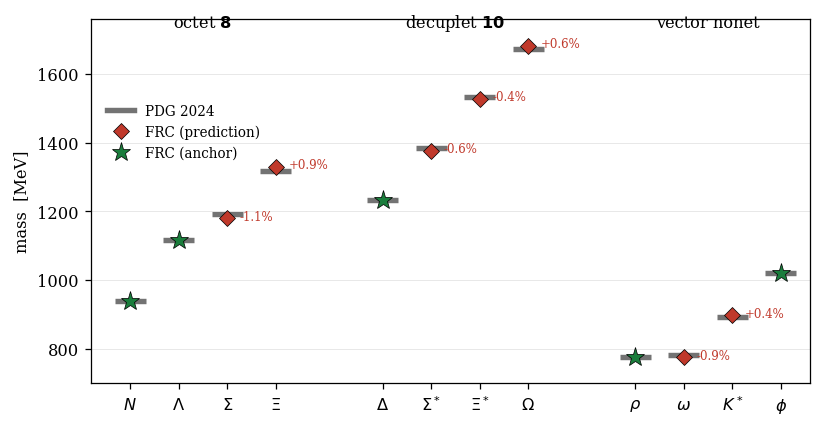

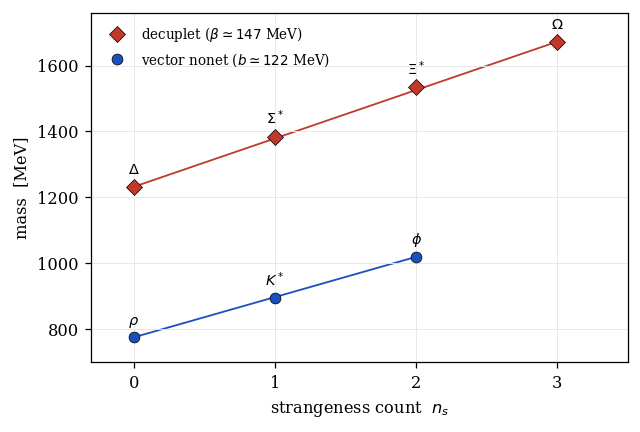

PASS fig_spectrum.pdf (and .png) regenerated in figures/
PASS fig_strangeness.pdf (and .png) regenerated in figures/
  [PASS] had.make_figures           CHART     [35:V2] the paper's two figures regenerated into figures/ from the exact values of absolute_masses  --  2 checks, 0.5 s


In [7]:
for fam in ["had.make_figures"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)

## Summary
Writes `results.json` (one record per family: id, the ledger row(s) witnessed, script, kind, claim, PASS/FAIL, the micro-check count) and raises if any family failed.

In [8]:
ok = gc.summary(write=True)
failed = [r["id"] for r in gc.RESULTS if not r["ok"]]
assert ok, f"FAILED families: {failed}"
print(f"all {len(gc.RESULTS)} families pass ({len(gc.MICRO)} micro-checks); records in results.json")


SUMMARY: 16/16 checks passed (65 micro-checks)
all 16 families pass (65 micro-checks); records in results.json
